# Student Performance Analysis

This project analyzes factors affecting student exam performance using a dataset of 6642 students.
The dataset contains 20 features including study habits, attendance, sleep hours, family income,
parental involvement, and school type across both public and private schools.

**Goal:** Analyze students score and identify which factors affect students marks the most,


**Dataset:** Student Performance Factors from Kaggle

# Questions

1. What is the average Exam_Score per Motivation_Level?
2. Which Gender has a higher average Exam_Score?
3. Do students with Internet_Access score higher?
4. What is the average Hours_Studied per Family_Income?
5. How many students have Learning_Disabilities and what is their average score?
6. Public schools vs private schools distribution and average grades.
7. What is the distribution of the exam marks?
8. Correlation between Hours_Studied, Attendance, Sleep_Hours and Exam_Score.
9. Tutoring_Sessions vs Exam_Score.
10. Does school and parents income affect score?
11. Can "high effort" overcome socioeconomic barriers?
12. Does studying more always lead to a better score?
13. Top 10% students vs bottom 10% students.
14. What's the routine of the students with high attendance?
15. What is the most common motivation level among top scorers (above 85)?

# 1- Understanding data


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('Dirty_StudentPerformanceFactors.csv', )
df.describe()


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,7624.000000,7647.000000,7647.000000,7647.000000,7647.000000,7647.000000,7647.000000
mean,14.534365,84.054400,7.002354,74.467373,1.504904,2.978946,88.199294
std,5.002282,9.508943,1.218157,11.824705,1.233076,2.002013,10.401552
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,-20.000000
25%,11.000000,77.000000,6.000000,66.000000,1.000000,1.000000,82.000000
50%,14.000000,84.000000,7.000000,75.000000,1.000000,3.000000,89.000000
75%,18.000000,91.000000,8.000000,83.000000,2.000000,5.000000,97.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,150.000000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7647 entries, 0 to 7646
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               7624 non-null   float64
 1   Attendance                  7647 non-null   int64  
 2   Parental_Involvement        7647 non-null   str    
 3   Access_to_Resources         7647 non-null   str    
 4   Extracurricular_Activities  7647 non-null   str    
 5   Sleep_Hours                 7647 non-null   int64  
 6   Previous_Scores             7647 non-null   int64  
 7   Motivation_Level            7647 non-null   str    
 8   Internet_Access             7647 non-null   str    
 9   Tutoring_Sessions           7647 non-null   int64  
 10  Family_Income               7647 non-null   str    
 11  Teacher_Quality             7555 non-null   str    
 12  School_Type                 7647 non-null   str    
 13  Peer_Influence              7647 non-null   

In [ ]:
df.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,14.0,89,Low,High,No,9,88,Low,Yes,0,Medium,Medium,Private,Positive,0,No,High School,Moderate,Female,91
1,16.0,65,Medium,Medium,No,9,75,High,Yes,0,High,Low,Public,Negative,0,No,High School,Moderate,Female,98
2,18.0,82,Low,High,Yes,7,96,Low,Yes,0,Medium,High,Public,Positive,6,Yes,College,Near,Female,88
3,13.0,77,High,Medium,Yes,9,78,Low,Yes,2,Medium,Medium,Private,Negative,0,No,High School,Moderate,Male,88
4,15.0,83,Medium,Low,No,6,64,MEDIUM,Yes,2,Medium,Low,Public,Neutral,6,No,High School,Far,Female,88
5,18.0,95,Medium,High,No,7,91,Medium,No,2,High,Medium,Public,Neutral,2,No,College,Moderate,Male,95
6,20.0,90,Low,Medium,Yes,5,50,Medium,No,2,Medium,Medium,Private,Positive,6,No,High School,Moderate,Male,84
7,15.0,87,High,Medium,No,10,86,MEDIUM,No,0,Low,Medium,Public,Negative,4,No,High School,Moderate,Male,82
8,14.0,85,Medium,High,Yes,7,83,Low,Yes,3,High,High,Private,Positive,4,No,High School,Moderate,Female,100
9,8.0,81,Medium,Medium,Yes,7,66,High,Yes,1,High,High,Private,Neutral,4,Yes,College,Near,Female,96


# 2- Data preprocessing


## Check data for duplicated and remove them

In [ ]:
df.duplicated().sum()

np.int64(1005)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated().sum()

np.int64(0)

## Check Data for missing values





In [ ]:
df.isnull().sum()

Hours_Studied                 18
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


Fixing Data type of hours_studied column



We need to deal with these NaN values before converting them to integers

so we will convert them from string to a float (because floats can store NaN)

then compute the mean in missin values and conver

In [ ]:
df['Hours_Studied'] = pd.to_numeric(df['Hours_Studied'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 6642 entries, 0 to 7512
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6624 non-null   float64
 1   Attendance                  6642 non-null   int64  
 2   Parental_Involvement        6642 non-null   str    
 3   Access_to_Resources         6642 non-null   str    
 4   Extracurricular_Activities  6642 non-null   str    
 5   Sleep_Hours                 6642 non-null   int64  
 6   Previous_Scores             6642 non-null   int64  
 7   Motivation_Level            6642 non-null   str    
 8   Internet_Access             6642 non-null   str    
 9   Tutoring_Sessions           6642 non-null   int64  
 10  Family_Income               6642 non-null   str    
 11  Teacher_Quality             6564 non-null   str    
 12  School_Type                 6642 non-null   str    
 13  Peer_Influence              6642 non-null   str  

In [ ]:
df['Hours_Studied'] = df['Hours_Studied'].fillna(df['Hours_Studied'].median())

In [ ]:
df['Hours_Studied'] = df['Hours_Studied'].astype(int) 

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 6642 entries, 0 to 7512
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6642 non-null   int64
 1   Attendance                  6642 non-null   int64
 2   Parental_Involvement        6642 non-null   str  
 3   Access_to_Resources         6642 non-null   str  
 4   Extracurricular_Activities  6642 non-null   str  
 5   Sleep_Hours                 6642 non-null   int64
 6   Previous_Scores             6642 non-null   int64
 7   Motivation_Level            6642 non-null   str  
 8   Internet_Access             6642 non-null   str  
 9   Tutoring_Sessions           6642 non-null   int64
 10  Family_Income               6642 non-null   str  
 11  Teacher_Quality             6564 non-null   str  
 12  School_Type                 6642 non-null   str  
 13  Peer_Influence              6642 non-null   str  
 14  Physical_Activity       

## Handle outliers

In [ ]:
df.describe()


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6642.000000,6642.000000,6642.000000,6642.000000,6642.000000,6642.000000,6642.000000
mean,14.571665,84.098615,7.010840,74.449864,1.501204,2.976212,88.244204
std,5.021148,9.488471,1.224113,11.800899,1.232893,2.004146,10.355973
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,-20.000000
25%,11.000000,77.000000,6.000000,66.000000,1.000000,1.000000,82.000000
50%,15.000000,85.000000,7.000000,75.000000,1.000000,3.000000,89.000000
75%,18.000000,91.000000,8.000000,83.000000,2.000000,5.000000,97.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,150.000000


In [ ]:
from datasist.structdata import detect_outliers
detect_outliers(df, 0, ['Exam_Score', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores'])

[106,
 203,
 322,
 380,
 547,
 890,
 917,
 941,
 1704,
 1867,
 1922,
 2030,
 2075,
 2114,
 2202,
 2279,
 2333,
 2560,
 2616,
 2999,
 3284,
 3325,
 3515,
 3619,
 4032,
 4552,
 4747,
 4981,
 5329,
 5795,
 5914,
 6015,
 6263,
 6333,
 6447,
 6546,
 6607,
 6611,
 33,
 718,
 1527,
 1939,
 2065,
 2524,
 2827,
 3240,
 3541,
 3809,
 3970,
 4156,
 4802,
 4881,
 4944,
 4968,
 5023,
 5082,
 5471,
 5549,
 5624,
 6446,
 6508]

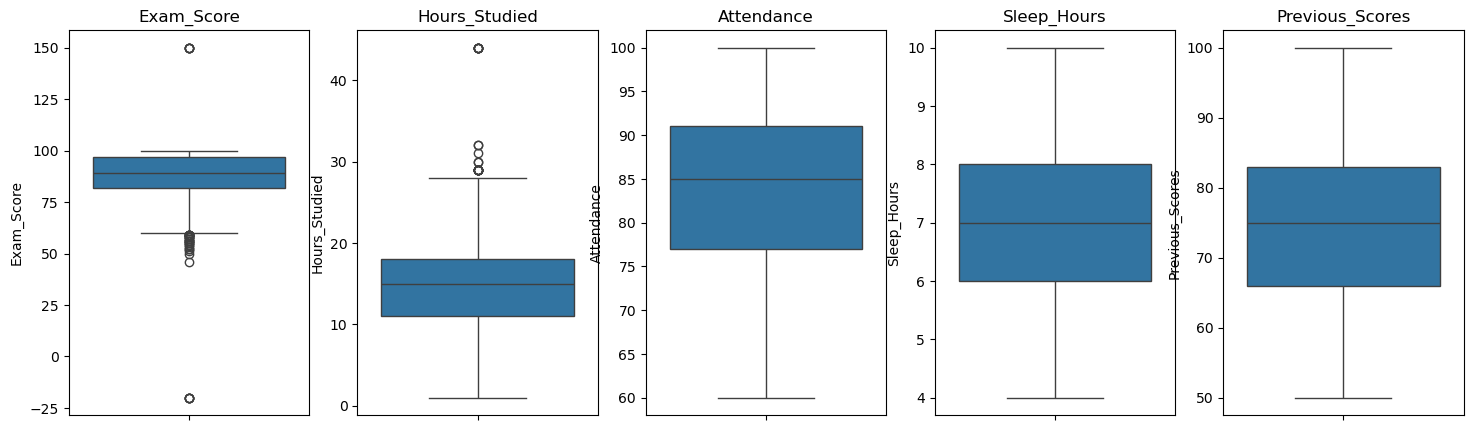

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
cols = ['Exam_Score', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)


plt.show()

Exam_Score and Hours_Studied columns  has some extreme values

In [ ]:
def fix_outliers(df, col, min_val, max_val):
    mean = int(df.loc[(df[col] >= min_val) & (df[col] <= max_val), col].mean())
    df.loc[df[col] > max_val, col] = mean
    df.loc[df[col] < min_val, col] = mean
    return df

df = fix_outliers(df, 'Exam_Score', 0, 100)
df = fix_outliers(df, 'Hours_Studied', 1, 44)



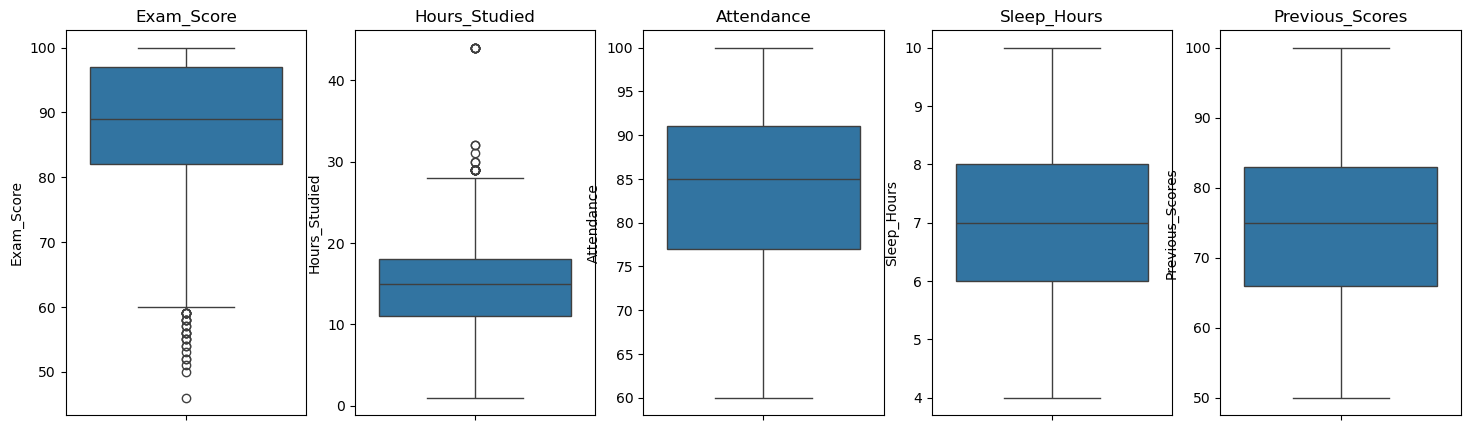

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
cols = ['Exam_Score', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)


plt.show()

## Handle inconsistent formatting in motivation_level column


In [ ]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,14,89,Low,High,No,9,88,Low,Yes,0,Medium,Medium,Private,Positive,0,No,High School,Moderate,Female,91
1,16,65,Medium,Medium,No,9,75,High,Yes,0,High,Low,Public,Negative,0,No,High School,Moderate,Female,98
2,18,82,Low,High,Yes,7,96,Low,Yes,0,Medium,High,Public,Positive,6,Yes,College,Near,Female,88
3,13,77,High,Medium,Yes,9,78,Low,Yes,2,Medium,Medium,Private,Negative,0,No,High School,Moderate,Male,88
4,15,83,Medium,Low,No,6,64,MEDIUM,Yes,2,Medium,Low,Public,Neutral,6,No,High School,Far,Female,88


check if there are other columns with incorrect formatting

In [ ]:
for col in df.select_dtypes(include='str').columns:
    display(df[col].value_counts())

Parental_Involvement
Medium    3318
Low       1993
High      1331
Name: count, dtype: int64

Access_to_Resources
Low       2239
Medium    2231
High      2172
Name: count, dtype: int64

Extracurricular_Activities
Yes    3347
No     3295
Name: count, dtype: int64

Motivation_Level
Medium        1142
  Medium      1135
MEDIUM        1097
  High         633
High           627
HIGH           627
  Low          482
LOW            478
Low            421
Name: count, dtype: int64

Internet_Access
Yes    5352
No     1290
Name: count, dtype: int64

...

Peer_Influence
Positive    2218
Negative    2212
Neutral     2212
Name: count, dtype: int64

Learning_Disabilities
No     5936
Yes     706
Name: count, dtype: int64

Parental_Education_Level
High School     2659
College         2578
Postgraduate    1315
Name: count, dtype: int64

Distance_from_Home
Moderate    2234
Near        2187
Far         2154
Name: count, dtype: int64

Gender
Male      3354
Female    3288
Name: count, dtype: int64

In [ ]:
def fix_formatting(df, cols):
    for col in cols:
        df[col] = df[col].str.strip().str.title()
    return df

df = fix_formatting(df, ['Motivation_Level'])

In [ ]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,14,89,Low,High,No,9,88,Low,Yes,0,Medium,Medium,Private,Positive,0,No,High School,Moderate,Female,91
1,16,65,Medium,Medium,No,9,75,High,Yes,0,High,Low,Public,Negative,0,No,High School,Moderate,Female,98
2,18,82,Low,High,Yes,7,96,Low,Yes,0,Medium,High,Public,Positive,6,Yes,College,Near,Female,88
3,13,77,High,Medium,Yes,9,78,Low,Yes,2,Medium,Medium,Private,Negative,0,No,High School,Moderate,Male,88
4,15,83,Medium,Low,No,6,64,Medium,Yes,2,Medium,Low,Public,Neutral,6,No,High School,Far,Female,88


In [ ]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6642.000000,6642.000000,6642.000000,6642.000000,6642.000000,6642.000000,6642.000000
mean,14.571665,84.098615,7.010840,74.449864,1.501204,2.976212,88.278832
std,5.021148,9.488471,1.224113,11.800899,1.232893,2.004146,9.775076
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,46.000000
25%,11.000000,77.000000,6.000000,66.000000,1.000000,1.000000,82.000000
50%,15.000000,85.000000,7.000000,75.000000,1.000000,3.000000,89.000000
75%,18.000000,91.000000,8.000000,83.000000,2.000000,5.000000,97.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,100.000000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 6642 entries, 0 to 7512
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6642 non-null   int64
 1   Attendance                  6642 non-null   int64
 2   Parental_Involvement        6642 non-null   str  
 3   Access_to_Resources         6642 non-null   str  
 4   Extracurricular_Activities  6642 non-null   str  
 5   Sleep_Hours                 6642 non-null   int64
 6   Previous_Scores             6642 non-null   int64
 7   Motivation_Level            6642 non-null   str  
 8   Internet_Access             6642 non-null   str  
 9   Tutoring_Sessions           6642 non-null   int64
 10  Family_Income               6642 non-null   str  
 11  Teacher_Quality             6564 non-null   str  
 12  School_Type                 6642 non-null   str  
 13  Peer_Influence              6642 non-null   str  
 14  Physical_Activity       

In [ ]:
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    df[col] = df[col].fillna(df[col].mode()[0])



In [ ]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

# Questions

## 1- What is the average Exam_Score per Motivation_Level?

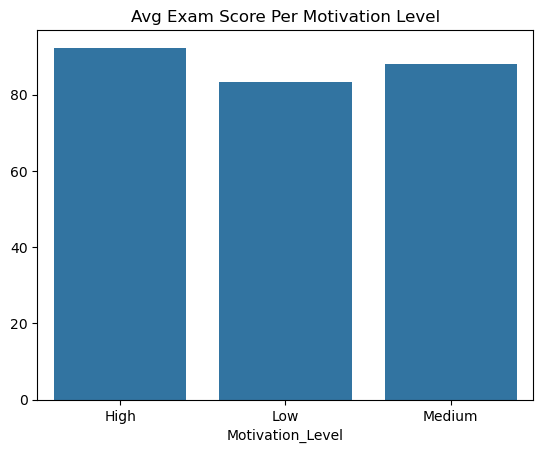

In [ ]:
res = df.groupby('Motivation_Level')['Exam_Score'].mean()
x,y = res.index,res.values
sns.barplot(x=x,y=y)
plt.title('Avg Exam Score Per Motivation Level')
plt.show()

## 2- Which Gender has a higher average Exam_Score

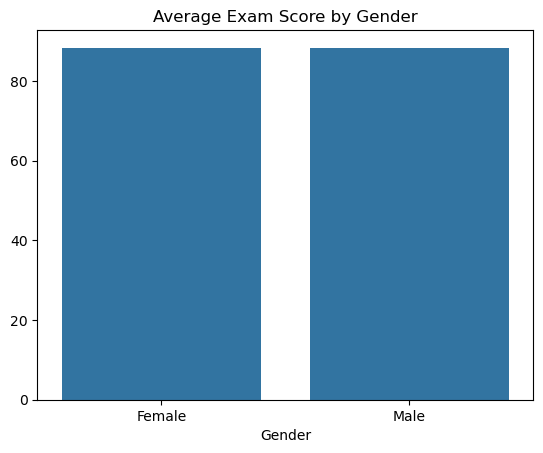

In [ ]:
res = df.groupby('Gender')['Exam_Score'].mean()
sns.barplot(x=res.index, y=res.values)
plt.title('Average Exam Score by Gender')
plt.show()

## 3- Do students with Internet_Access score higher

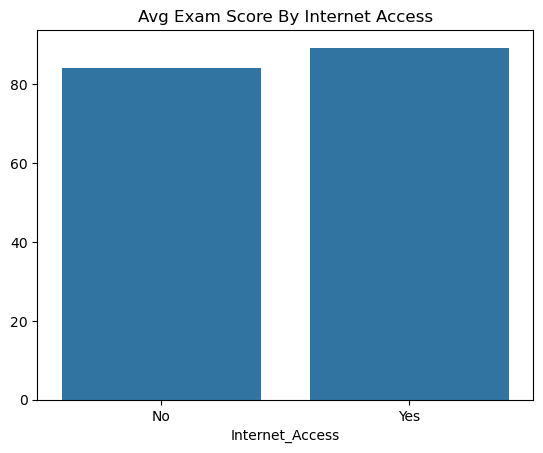

In [ ]:
res = df.groupby('Internet_Access')['Exam_Score'].mean()
x, y = res.index, res.values
sns.barplot(x=x, y=y)
plt.title('Avg Exam Score By Internet Access')
plt.show()

## 4- Average Hours_Studied per Family_Income

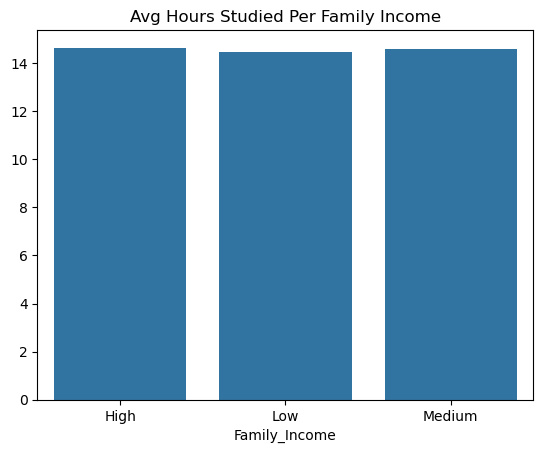

In [ ]:
res = df.groupby('Family_Income')['Hours_Studied'].mean()
x, y = res.index, res.values
sns.barplot(x=x, y=y)
plt.title('Avg Hours Studied Per Family Income')
plt.show()

## 5- How Many Students with Learning_Disabilities and their avg score

                       count       mean
Learning_Disabilities                  
No                      5936  88.708389
Yes                      706  84.667139


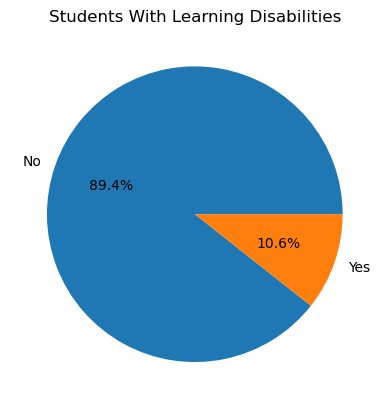

In [ ]:
res = df.groupby('Learning_Disabilities')['Exam_Score'].agg(['count', 'mean'])
print(res)
sizes = df['Learning_Disabilities'].value_counts()
x, y = sizes.index, sizes.values
plt.pie(y, labels=x, autopct='%1.1f%%')
plt.title('Students With Learning Disabilities')
plt.show()

## 6-Public schools vs private schools distribution and average grades

School_Type
Private    89.618037
Public     87.748161
Name: Exam_Score, dtype: float64


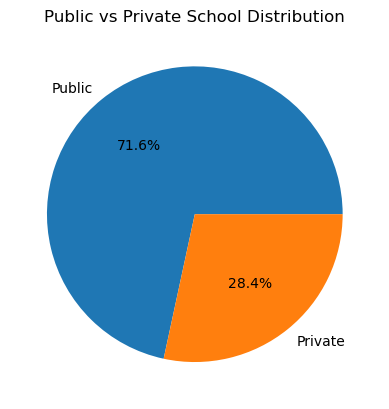

In [ ]:
res = df.groupby('School_Type')['Exam_Score'].mean()
print(res)
sizes = df['School_Type'].value_counts()
x, y = sizes.index, sizes.values
plt.pie(y, labels=x, autopct='%1.1f%%')
plt.title('Public vs Private School Distribution')
plt.show()

## 7- What is the distribution of the exam marks

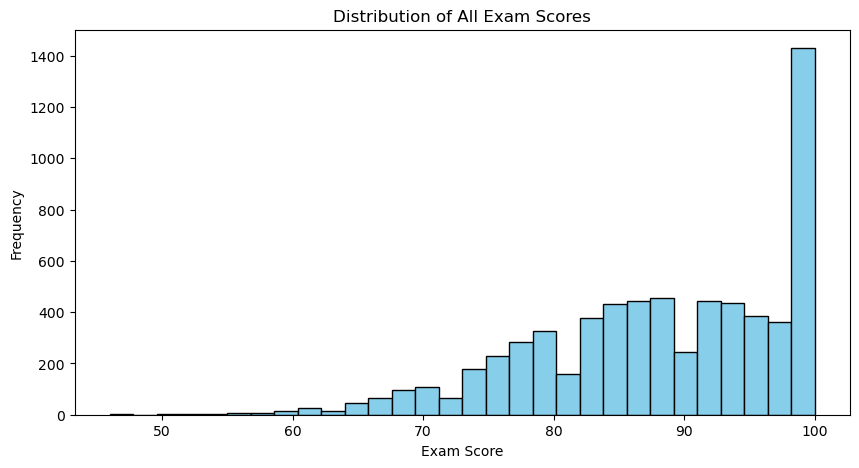

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df['Exam_Score'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of All Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

## 8- Correlation between Hours_Studied, Attendance, Sleep_Hours and Exam_Score

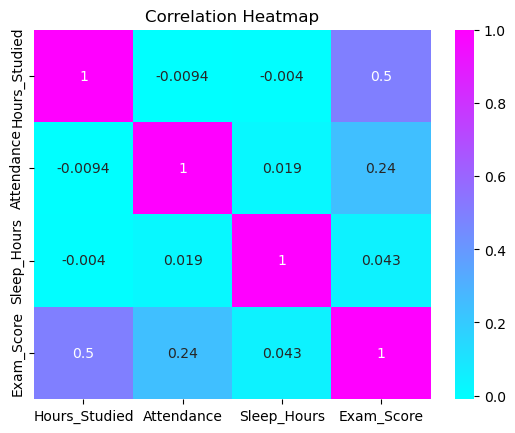

In [ ]:
cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Exam_Score']
sns.heatmap(df[cols].corr(), annot=True, cmap='cool')
plt.title('Correlation Heatmap')
plt.show()

## 9- Tutoring_Sessions vs Exam_Score

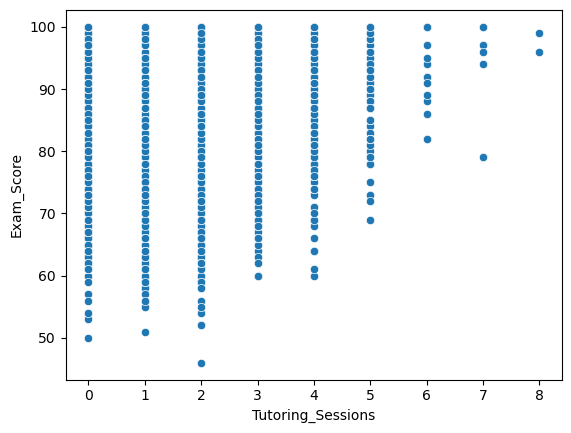

In [ ]:
sns.scatterplot(x="Tutoring_Sessions",y="Exam_Score",data = df)
plt.show()

## 10- Does school and parents income affect score?

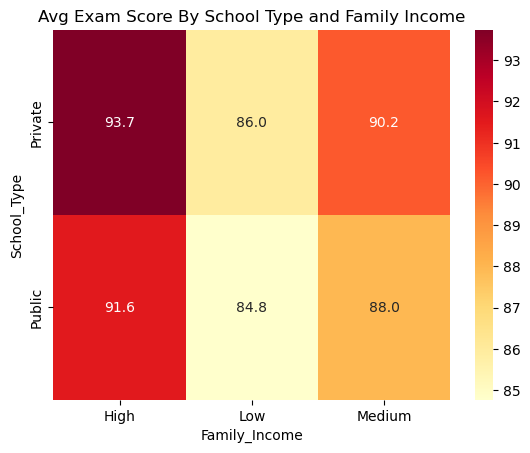

In [ ]:
pivot = pd.pivot_table(df, index='School_Type', columns='Family_Income', values='Exam_Score', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Avg Exam Score By School Type and Family Income')
pivot = pivot[['Low', 'Medium', 'High']]
plt.show()

 ## 11- can "high effort" can overcome socioeconomic barriers.

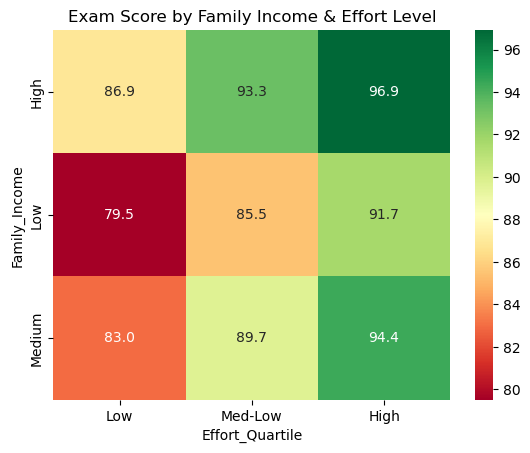

In [ ]:
df['Effort_Score'] = df['Hours_Studied'] + (df['Tutoring_Sessions'] * 2)
df['Effort_Quartile'] = pd.qcut(df['Effort_Score'], 3, labels=['Low', 'Med-Low', 'High'])
res = df.groupby(['Family_Income', 'Effort_Quartile'])['Exam_Score'].mean().unstack()

sns.heatmap(res, annot=True, cmap='RdYlGn', fmt='.1f')
plt.title('Exam Score by Family Income & Effort Level')
plt.show()

## 12- Does studying more always lead to a better score

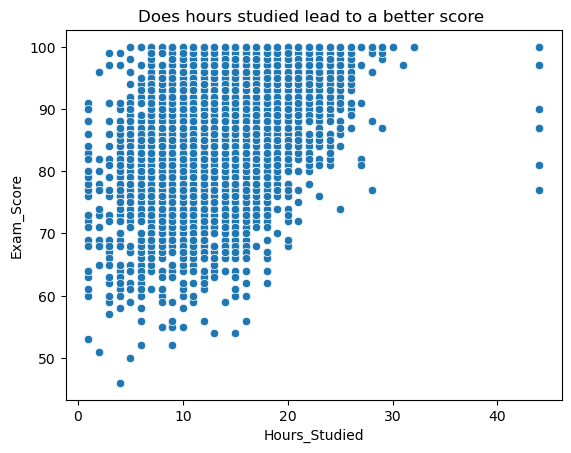

In [ ]:
sns.scatterplot(x="Hours_Studied", y ='Exam_Score', data = df)
plt.title('Does hours studied lead to a better score ')
plt.show()

## 13- top 10% students vs bottom 10% students

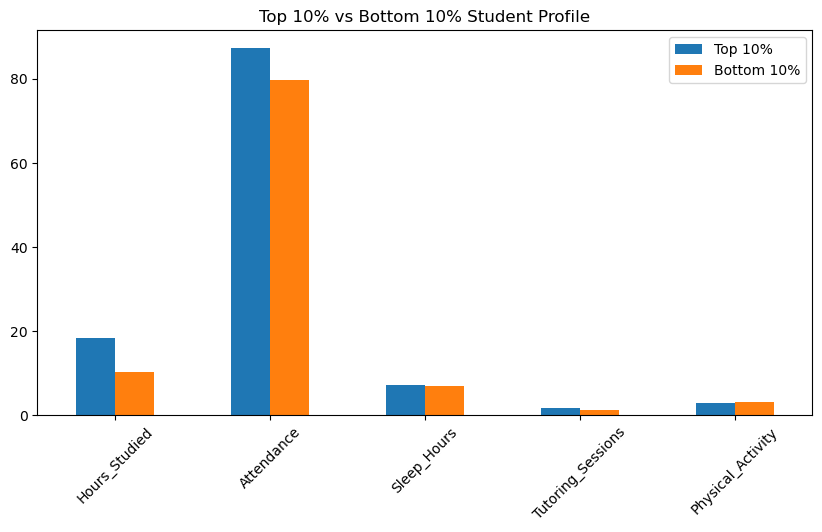

In [ ]:
top = df[df['Exam_Score'] >= df['Exam_Score'].quantile(0.90)]
bottom = df[df['Exam_Score'] <= df['Exam_Score'].quantile(0.10)]

cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Tutoring_Sessions', 'Physical_Activity']
comparison = pd.DataFrame({
    'Top 10%': top[cols].mean(),
    'Bottom 10%': bottom[cols].mean()
})

comparison.plot(kind='bar', figsize=(10, 5))
plt.title('Top 10% vs Bottom 10% Student Profile')
plt.xticks(rotation=45)
plt.show()

## 14- What's the routine of the students with high attendance

In [ ]:
df[df['Attendance'] > 90][['Exam_Score', 'Hours_Studied', 'Attendance']]


,Exam_Score,Hours_Studied,Attendance
5,95,18,95
16,73,6,94
23,80,16,93
30,88,16,100
32,97,15,100
...,...,...,...
7211,81,11,92
7238,100,18,100
7290,82,12,94
7326,96,15,98


In [ ]:
df[df['Attendance'] > 90][['Exam_Score', 'Hours_Studied']].mean()

Exam_Score       91.058242
Hours_Studied    14.385714
dtype: float64

## 15-  What is the most common motivation level among top scorers (above 85)

In [ ]:
df[df['Exam_Score'] > 85]['Motivation_Level'].value_counts()

Motivation_Level
Medium    2096
High      1495
Low        606
Name: count, dtype: int64

Cleaned dataset saved to Cleaned_StudentPerformanceFactors.csv
